In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json


descrips = ['white, blue, large', 'white, blue, small', 'white, red, large', 'black, blue, large', 
            'white, red, small', 'black, blue, small', 'black, red, large', 'black, red, small']
            
configs = ['000','001','010','100','011','101','110','111' ]
seed = 0
category_config = 'all'

folder_path = f"/data2/amanda/LLM-Understanding/concept_graphs/output/bg_color_size/cauchy_01/H32-train1/all"


000
white, blue, large
001
white, blue, small
010
white, red, large
100
black, blue, large
011
white, red, small
101
black, blue, small
110
black, red, large
111
black, red, small


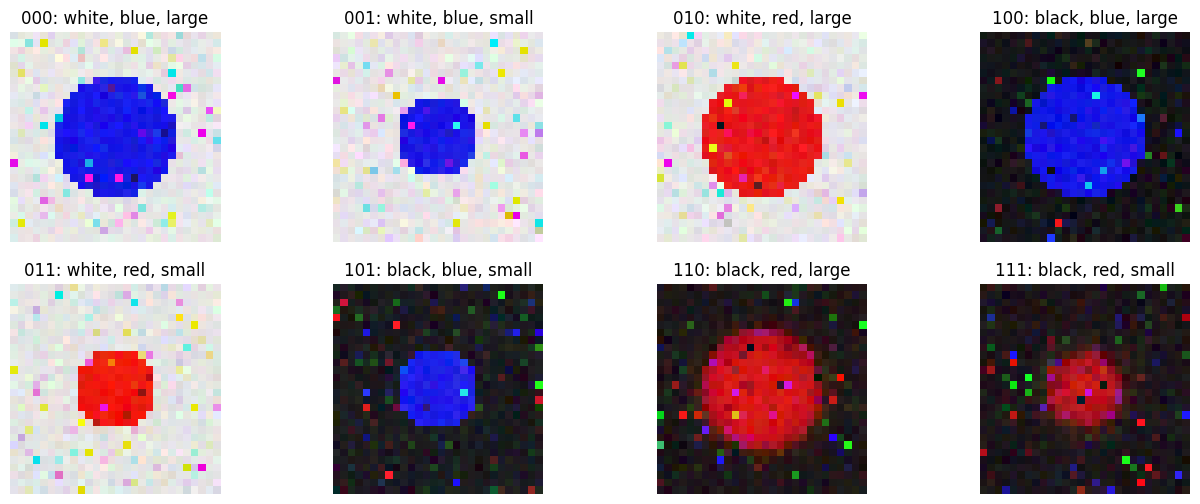

In [8]:
os.makedirs(folder_path, exist_ok=True)

#stored_ep = [99, 199, 299, 399, 499]
stored_ep = [399]

for ep in stored_ep:
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    for idx, config in enumerate(configs):
        print(config)
        print(descrips[idx])
        file_path = folder_path + f"/image_{config}_ep{ep}.npz"

        # Load the .npz file
        data = np.load(file_path)

        # List all arrays in the file
        keys = data.files
        #print("Keys in NPZ file:", keys)

        # Plot a few images from each array
        for key in keys:
            images = data[key] 

            # Loop through the first batch and first few images
            for i in range(1):  # Display 5 images
                # img = images[0, i]  # First batch, ith image (Shape: 3, 28, 28)
                img = images[i] # ith image (Shape: 3, 28, 28)

                # Transpose to (28, 28, 3) for imshow
                img = np.transpose(img, (1, 2, 0))
                img = img.clip(0, 1)
                
                #plt.figure()
                #plt.title(config)
                #plt.imshow(img)
                #plt.axis('off')
                axes[idx].imshow(img)
                axes[idx].set_title(config + f": {descrips[idx]}")
                axes[idx].axis('off')
        #plt.show()

        # Close the file
        data.close()
    fig.savefig(folder_path + f"/all_01_ep{ep}.png", bbox_inches='tight')


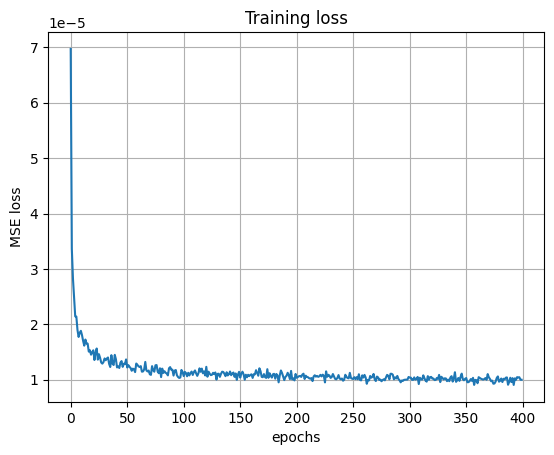

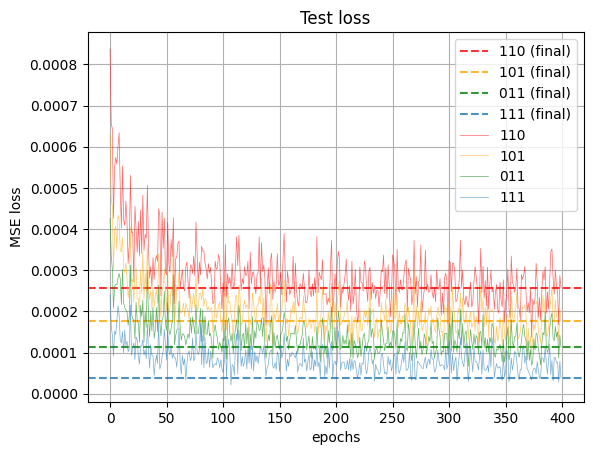

0.0002570658512413502
0.00017662153020501137
0.00011316082999110222
3.845527395606041e-05


In [9]:
with open(folder_path + f"/loss_log399.json", 'r') as f:
    loss_log = json.load(f)
train_loss_per_epoch = loss_log["train_loss_per_epoch"]
test_loss_110 = loss_log["test_loss_per_epoch"]["110"]
test_loss_101 = loss_log["test_loss_per_epoch"]["101"]
test_loss_011 = loss_log["test_loss_per_epoch"]["011"]
test_loss_111 = loss_log["test_loss_per_epoch"]["111"]

plt.figure()
plt.plot(train_loss_per_epoch)
plt.title("Training loss")
plt.xlabel("epochs")
plt.ylabel("MSE loss")
plt.grid(True)
#plt.savefig(folder_path + f"/loss_log499.png", bbox_inches="tight")
plt.show()

plt.figure()
#plt.plot([test_loss_110[-1], test_loss_101[-1], test_loss_011[-1], test_loss_111[-1]])
plt.axhline(y=test_loss_110[-1], linestyle='--', color='red', alpha=0.8, label='110 (final)')
plt.axhline(y=test_loss_101[-1], linestyle='--',  color='orange', alpha=0.8, label='101 (final)')
plt.axhline(y=test_loss_011[-1], linestyle='--', color='green', alpha=0.8, label='011 (final)')
plt.axhline(y=test_loss_111[-1], linestyle='--', alpha=0.8, label='111 (final)')

#plt.plot([test_loss_110[-1], test_loss_101[-1], test_loss_011[-1], test_loss_111[-1]])
plt.plot(test_loss_110, color='red', linewidth=0.5, alpha=0.6, label='110')
plt.plot(test_loss_101, color='orange', linewidth=0.5, alpha=0.6, label='101')
plt.plot(test_loss_011, color='green', linewidth=0.5, alpha=0.6, label='011')
plt.plot(test_loss_111, linewidth=0.5, alpha=0.6, label='111')
plt.legend()
plt.title("Test loss")
plt.xlabel("epochs")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

print(test_loss_110[-1])
print(test_loss_101[-1])
print(test_loss_011[-1])
print(test_loss_111[-1])